[![Text: CC BY-SA 4.0](https://img.shields.io/badge/text-CC%20BY--SA%204.0-lightgrey.svg)](https://creativecommons.org/licenses/by-sa/4.0/)
[![Code: MIT](https://img.shields.io/badge/code-MIT-yellow.svg)](https://opensource.org/license/mit)

This notebook is part of course materials for CS 545: Machine Learning at
Colorado State University. These notebooks are based on the PyTorch version of
[Dive into Deep Learning](https://d2l.ai) by Aston Zhang, Zachary C. Lipton,
Mu Li and Alexander J. Smola, used under
[CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/) and heavily
modified by [Asa Ben-Hur](https://www.cs.colostate.edu/~asa/) with
[Claude](https://claude.com) AI. The text is released under
[CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/); the code is
released under the [MIT license](https://opensource.org/license/mit).

# Softmax Regression: Implementation from Scratch

Because softmax regression is so fundamental, we believe that you ought to know
how it is implemented.

In [1]:
import torch
from torch import nn
import numpy as np
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [2]:
# if you have a GPU we should enable it
# mps is the pytorch device that supports GPU computations on MacOS

device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using mps device


## Image data

In the previous notebooks we used PyTorch to solve toy problems.  In this notebook, we'll look at the real (but still relatively easy) problem of handwritten digit recognition.  We will use the **Fashion-MNIST** dataset, which is an alternative "hello-world" image dataset, replacing the old MNIST handwritten digit dataset (note that MNIST stands for "modified National Institute of Standards and Technology").
While no longer useful for demonstrating state-of-the-art advancements in machine learning, as a dataset, both MNIST datasets will live on for a long time as both teaching tools and also some degree as a testbed for ideas aimed at better explaining the behavior of machine learning algorithms.  The original MNIST dataset has been used in thousands of machine learning publications, and is described in this [Wikipedia article](https://en.wikipedia.org/wiki/MNIST_database).

The first thing we need to do is to load the dataset.  Here's a function that provides data loaders for the data:

In [3]:
def load_fashion_mnist(batch_size, resize=None):
    trans = [transforms.ToTensor()]
    if resize:
        trans.insert(0, transforms.Resize(resize))
    trans = transforms.Compose(trans)
    
    train_dataset = datasets.FashionMNIST(
        root='../data',
        train=True,
        download=True,
        transform=trans
    )
    test_dataset = datasets.FashionMNIST(
        root='../data',
        train=False,
        download=True,
        transform=trans
    )
    
    return (
        DataLoader(train_dataset, batch_size=batch_size, shuffle=True),
        DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    )

In [4]:
train_loader, valid_loader = load_fashion_mnist(batch_size=256)

Let's create a data loader and take a look at a few images:

In [5]:
X,y = next(iter(train_loader))
X.shape,y.shape

(torch.Size([256, 1, 28, 28]), torch.Size([256]))

In [6]:
X[0][0].min(),X[0][0].max()

(tensor(0.), tensor(1.))

We note that most modern image data has three channels (red, green, blue) and that hyperspectral images can have in excess of 100 channels (the HyMap sensor has 126 channels).
By convention we store an image as a $c \times h \times w$ tensor, where $c$ is the number of color channels, $h$ is the height and $w$ is the width.

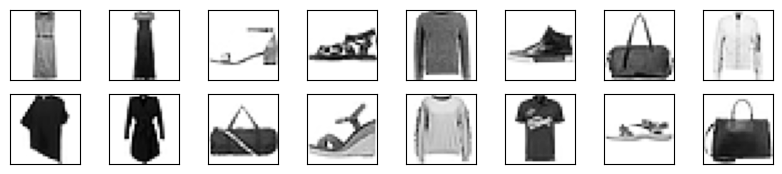

In [7]:
from matplotlib import pyplot as plt
figsize=(10, 2)
num_rows = 2
num_cols = 8
_, axes = plt.subplots(num_rows, num_cols, figsize=figsize)
axes = axes.flatten()
imgs = X[:len(axes)]
for i, (ax, img) in enumerate(zip(axes, imgs)):
    img = img.numpy()[0]
    ax.imshow(img, cmap='Greys')
    ax.axes.get_xaxis().set_visible(False)
    ax.axes.get_yaxis().set_visible(False)

Fashion-MNIST consists of images from 10 categories, each represented
by 6000 images in the training dataset and by 1000 in the test dataset.
Consequently the training set and the test set
contain 60,000 and 10,000 images, respectively.

In [8]:
len(train_loader)

235

In [9]:
len(train_loader)*256

60160

## The Softmax Function

Let's begin with the mapping from scores to probabilities with the softmax function.
For a refresher, recall that the `sum` operation can be performed
along specific dimensions in a tensor using the
`axis` parameter, which lets us compute row and column sums:


In [10]:
X_demo = torch.tensor([[1.0, 2.0, 3.0], [4.0, 5.0, 6.0]])
print(X_demo)
X_demo.sum(axis=0, keepdims=True), X_demo.sum(axis=1, keepdims=True)

tensor([[1., 2., 3.],
        [4., 5., 6.]])


(tensor([[5., 7., 9.]]),
 tensor([[ 6.],
         [15.]]))

Computing the softmax requires three steps:
(i) exponentiation of each term;
(ii) a sum over each row to compute the normalization constant for each example;
(iii) division of each row by its normalization constant, ensuring that the result sums to 1:

$$\mathrm{softmax}(\mathbf{X})_{ij} = \frac{\exp(\mathbf{X}_{ij})}{\sum_k \exp(\mathbf{X}_{ik})}.$$

The implementation is straightforward:

In [11]:
def softmax(X):
    X_exp = torch.exp(X) 
    return X_exp / X_exp.sum(axis=1, keepdims=True) #  broadcasting is applied here

In [12]:
X_demo = torch.rand((2, 5))
X_prob = softmax(X_demo)
print("original tensor: ")
print(X_demo)
print("after softmax: ")
print(X_prob)
print("verify rows sum up to 1:")
X_prob.sum(axis=1)

original tensor: 
tensor([[0.4953, 0.5083, 0.8142, 0.4567, 0.3117],
        [0.5841, 0.8001, 0.5028, 0.7260, 0.2668]])
after softmax: 
tensor([[0.1929, 0.1955, 0.2654, 0.1856, 0.1606],
        [0.1983, 0.2461, 0.1828, 0.2285, 0.1444]])
verify rows sum up to 1:


tensor([1., 1.])

**Caution:** the code above is *not* robust against very large or very small arguments. While it is sufficient to illustrate what is happening, you should *not* use this code for any serious purpose. Deep learning frameworks have such protections built in and we will be using the built-in softmax going forward.


In [13]:
X_demo = torch.rand((2, 5)) * 100
print(X_demo)
softmax(X_demo)

tensor([[ 1.3250, 82.4196, 46.5013, 48.2378, 78.0237],
        [80.0339, 90.0676, 90.7807, 31.9464, 30.9634]])


tensor([[5.9667e-36, 9.8782e-01, 2.4862e-16, 1.4115e-15, 1.2177e-02],
        [0.0000e+00,        nan,        nan, 0.0000e+00, 0.0000e+00]])

## The Model

We now have everything that we need
to implement the softmax regression model.
As in our linear regression example,
each instance will be represented
by a fixed-length vector.
Since the raw data here consists of images that are $28 \times 28$ matrices of raw pixel data, we flatten each image into vectors of length 784.
Later in the course we will introduce convolutional neural networks, which were specifically designed with image data in mind and exploit their spatial structure in a more satisfying way.

**Network parameters**.
In softmax regression, the number of outputs from our network should be equal to the number of classes.
Since our dataset has 10 classes, our network has an output dimension of 10.
Consequently, our weights constitute a $784 \times 10$ matrix plus a $1 \times 10$ row vector for the biases.
As with linear regression, we initialize the weights `W` with Gaussian noise.
The biases are initialized as zeros.

In [14]:
class SoftmaxRegressionScratch(nn.Module):
    def __init__(self, num_inputs, num_outputs, sigma=0.01):
        super().__init__()
        self.W = nn.Parameter(torch.normal(0, sigma, size=(num_inputs, num_outputs)))
        #self.W = torch.normal(0, sigma, size=(num_inputs, num_outputs),
        #                      requires_grad=True)
        self.b = nn.Parameter(torch.zeros(num_outputs))
        #self.b = torch.zeros(num_outputs, requires_grad=True)
    def forward(self, X):
        #X = X.reshape((-1, self.W.shape[0]))
        X = torch.flatten(X, start_dim=1)
        return softmax(torch.matmul(X, self.W) + self.b)

# no longer required since we are using nn.Parameter:        
#    def parameters(self):
#        return [self.W, self.b]

In [15]:
model = SoftmaxRegressionScratch(784, 10)
# reuse the loaders created above rather than reloading the dataset
X, y = next(iter(train_loader))

In [16]:
X.shape

torch.Size([256, 1, 28, 28])

In [17]:
Y_pred = model(X)   # uses nn.Module.__call__, the idiomatic form

In [18]:
Y_pred.shape

torch.Size([256, 10])

In [19]:
Y_pred[0]

tensor([0.1152, 0.0987, 0.0995, 0.1100, 0.0911, 0.0872, 0.1230, 0.0883, 0.0837,
        0.1033], grad_fn=<SelectBackward0>)

In [20]:
y[0]

tensor(2)

## The Cross-Entropy Loss

Next we implement the cross-entropy loss function.
It is perhaps the most common loss function in deep learning.

Recall the expression for the cross-entropy loss function:

$$ l(\mathbf{y}, \hat{\mathbf{y}}) = - \sum_{j=1}^q y_j \log \hat{y}_j. $$

where $\mathbf{y}$ is the label and the model prediction is $\hat{\mathbf{y}}$, and $q$ is the number of classes.

To illustrate the computation that is needed in evaluating cross entropy let's
create toy data `y_hat` with 2 examples of predicted probabilities over 3 classes and their corresponding labels `y`.
Using `y` as the indices of the probabilities in `y_hat`, we can pick out the terms needed for computing the loss function:


In [21]:
y = torch.tensor([0, 2])
y_hat = torch.tensor([[0.1, 0.3, 0.6], [0.3, 0.2, 0.5]])
y_hat[range(len(y_hat)), y]
# Note that for multi-dimensional fancy indexing, PyTorch flattens to 1D, making this
# different than y_hat[:, y]

tensor([0.1000, 0.5000])

In [22]:
-torch.log(y_hat[range(len(y_hat)), y])

tensor([2.3026, 0.6931])

In [23]:
y_hat[:, y]

tensor([[0.1000, 0.6000],
        [0.3000, 0.5000]])

In [24]:
y_hat[range(len(y_hat)), y]

tensor([0.1000, 0.5000])

Now we can implement the cross-entropy loss function by averaging over the logarithms of the selected probabilities:


In [25]:
def cross_entropy(y_hat, y):
    return -torch.log(y_hat[torch.arange(len(y_hat)), y]).mean()

In [26]:
cross_entropy(y_hat, y)

tensor(1.4979)

## Training

Let's apply the softmax model to the FashionMNIST dataset.
> **A note on numerical stability.** We are deliberately training with the
> *numerically naive* softmax function defined above, which exponentiates the raw logits
> and then feeds the resulting probabilities into the `cross_entropy` computation.
> As the caution earlier in this notebook warned, this
> `log(exp(...))` round-trip can lead to overflow or underflow for large-magnitude logits.
> It works here only because the small weight initialization (`sigma=0.01`) keeps
> the logits small throughout training. We keep the naive version to stay faithful
> to a "from scratch" implementation; the next notebook switches to
> PyTorch's built-in `cross_entropy`, which fuses the log-softmax and the loss using
> the log-sum-exp trick and is stable by construction.

In [27]:
def train_epoch(model, train_loader, loss_fn, optimizer):
    model.train()
    total_loss = 0.0   # sum of per-example losses
    total_examples = 0
    for X, y in train_loader:
        X, y = X.to(device), y.to(device)
        y_pred = model(X)
        loss = loss_fn(y_pred, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        # loss_fn returns the mean over the batch, so multiply back out by the
        # batch size to accumulate an exact, example-weighted average (the final
        # batch is smaller, so a plain mean of batch means would be biased).
        total_loss += loss.item() * y.numel()
        total_examples += y.numel()
    return total_loss / total_examples


def correctly_classified(y_hat, y):
    """Return the NUMBER of correct predictions in a batch (not a rate)."""
    if len(y_hat.shape) > 1:
        y_hat = y_hat.argmax(dim=1)
    return (y_hat == y).type(torch.float32).sum().item()


def evaluate(model, loss_fn, data_loader):
    model.eval()
    total_loss = 0.0
    correct = 0.0
    total = 0
    with torch.no_grad():
        for X, y in data_loader:
            X, y = X.to(device), y.to(device)
            y_pred = model(X)
            total_loss += loss_fn(y_pred, y).item() * y.numel()
            correct += correctly_classified(y_pred, y)
            total += y.numel()
    return correct / total, total_loss / total

In [28]:
# train_loader / valid_loader were created once near the top of the notebook;
# we reuse them here so training, evaluation and prediction all use the same split.
model = SoftmaxRegressionScratch(num_inputs=784, num_outputs=10)
model = model.to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
loss_fn = cross_entropy

In [29]:
epochs = 15
# overall loss / accuracy value for each epoch:
train_losses, valid_losses, valid_accs = [], [] , []

for epoch in range(epochs) :
    print("epoch", epoch + 1)
    train_loss = train_epoch(model, train_loader, loss_fn, optimizer)
    valid_acc, valid_loss = evaluate(model, loss_fn, valid_loader)
    train_losses.append(train_loss)
    valid_losses.append(valid_loss)
    valid_accs.append(valid_acc)
    print ("loss", train_loss, "accuracy: ", valid_acc)

epoch 1
loss 1.3754358859380087 accuracy:  0.6808
epoch 2
loss 0.9195255366961161 accuracy:  0.7201
epoch 3
loss 0.8048757108052572 accuracy:  0.7454
epoch 4
loss 0.7441735883394877 accuracy:  0.7599
epoch 5
loss 0.7043517528851827 accuracy:  0.7694
epoch 6
loss 0.6753554763476054 accuracy:  0.7749
epoch 7
loss 0.652902583471934 accuracy:  0.783
epoch 8
loss 0.6347144148190816 accuracy:  0.787
epoch 9
loss 0.6198735233306885 accuracy:  0.7901
epoch 10
loss 0.6069845512708029 accuracy:  0.7954
epoch 11
loss 0.5960901835441589 accuracy:  0.7975
epoch 12
loss 0.5865593685309092 accuracy:  0.802
epoch 13
loss 0.5780334719022115 accuracy:  0.8033
epoch 14
loss 0.5705540723164876 accuracy:  0.806
epoch 15
loss 0.5636550954500834 accuracy:  0.8064


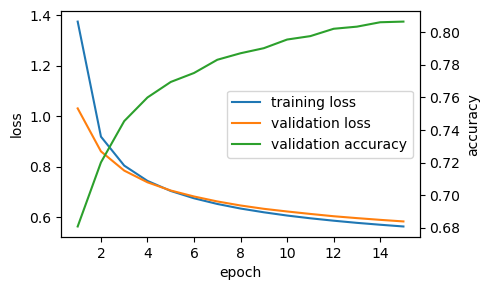

In [30]:
from matplotlib import pyplot as plt

epochs_axis = range(1, len(train_losses) + 1)
fig, ax_loss = plt.subplots(figsize=(5, 3))

# left y-axis: losses
l1 = ax_loss.plot(epochs_axis, train_losses, label='training loss')
l2 = ax_loss.plot(epochs_axis, valid_losses, label='validation loss')
ax_loss.set_xlabel('epoch')
ax_loss.set_ylabel('loss')

# right y-axis: accuracy (different scale, so give it its own axis)
ax_acc = ax_loss.twinx()
l3 = ax_acc.plot(epochs_axis, valid_accs, label='validation accuracy',
                 color='tab:green')
ax_acc.set_ylabel('accuracy')

# combine the legends from both axes into one
lines = l1 + l2 + l3
ax_loss.legend(lines, [ln.get_label() for ln in lines], loc='center right')
plt.tight_layout();

## Prediction

Now that training is complete,
our model is ready to classify some images.


In [31]:
X, y = next(iter(valid_loader))
X, y = X.to(device), y.to(device)
y_pred = model(X).argmax(axis=1)
print("first ten predictions and labels:")
print(y_pred[:10])
print(y[:10])

first ten predictions and labels:
tensor([9, 2, 1, 1, 6, 1, 4, 6, 7, 7], device='mps:0')
tensor([9, 2, 1, 1, 6, 1, 4, 6, 5, 7], device='mps:0')


It is often instructive to look at examples that are predicted *incorrectly*. Fashion-MNIST labels are integers 0--9, but each corresponds to a garment category, so we first define human-readable `class_names`. The visualization below scans the validation set for misclassified images and shows the first several, each titled with its true class (top) and the model's incorrect prediction (bottom). This makes the nature of the confusion readable at a glance — for instance *Shirt* vs *Coat* vs *Pullover*, which are genuinely similar garments.


In [32]:
# the 10 Fashion-MNIST categories, indexed by their integer label (0-9)
class_names = [
    "T-shirt/top",  # 0
    "Trouser",      # 1
    "Pullover",     # 2
    "Dress",        # 3
    "Coat",         # 4
    "Sandal",       # 5
    "Shirt",        # 6
    "Sneaker",      # 7
    "Bag",          # 8
    "Ankle boot",   # 9
]

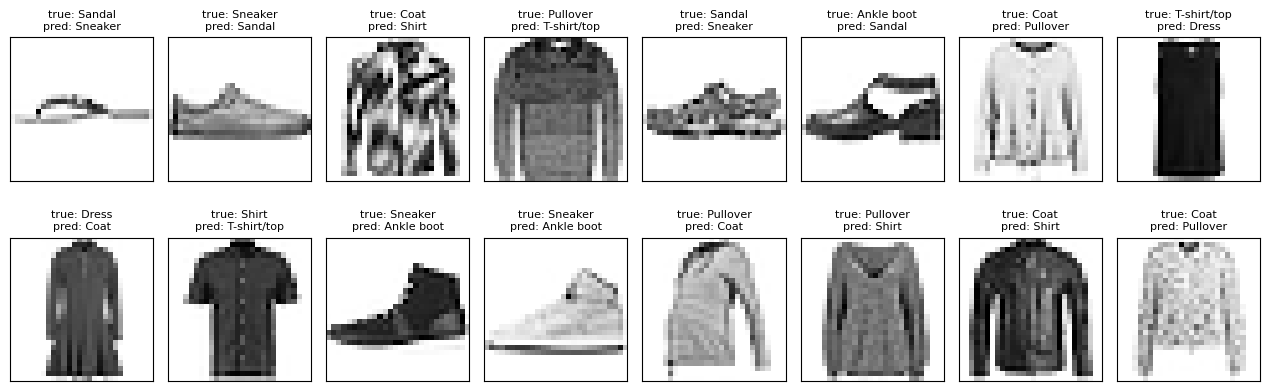

In [33]:
from matplotlib import pyplot as plt

# scan the validation set and collect misclassified examples
model.eval()
wrong_imgs, wrong_true, wrong_pred = [], [], []
num_to_show = 16

with torch.no_grad():
    for X, y in valid_loader:
        X, y = X.to(device), y.to(device)
        preds = model(X).argmax(dim=1)
        mismatch = preds != y
        if mismatch.any():
            wrong_imgs.append(X[mismatch].cpu())
            wrong_true.append(y[mismatch].cpu())
            wrong_pred.append(preds[mismatch].cpu())
        # stop once we have collected enough to display
        if sum(t.numel() for t in wrong_true) >= num_to_show:
            break

wrong_imgs = torch.cat(wrong_imgs)[:num_to_show]
wrong_true = torch.cat(wrong_true)[:num_to_show]
wrong_pred = torch.cat(wrong_pred)[:num_to_show]

num_cols = 8
num_rows = (num_to_show + num_cols - 1) // num_cols
_, axes = plt.subplots(num_rows, num_cols, figsize=(1.6 * num_cols, 2.2 * num_rows))
axes = axes.flatten()
for ax, img, t, p in zip(axes, wrong_imgs, wrong_true, wrong_pred):
    ax.imshow(img.numpy()[0], cmap='Greys')
    ax.set_title(f"true: {class_names[t]}\npred: {class_names[p]}", fontsize=8)
    ax.axes.get_xaxis().set_visible(False)
    ax.axes.get_yaxis().set_visible(False)
# hide any unused axes (if fewer than num_to_show were collected)
for ax in axes[len(wrong_imgs):]:
    ax.set_visible(False)
plt.tight_layout();

## Summary

By now we are starting to get some experience with solving linear regression and classification problems.
With it, we have reached what would arguably be the state of the art of 1960--1970s of statistical modeling.
In the next notebook, we see how to leverage PyTorch to implement this model more efficiently.

## Exercises

1. In this notebook, we implemented the softmax function directly based on its mathematical definition. This can cause numerical instabilities as we have seen.  Here is an alternative implementation (works for one dimensional NumPy arrays):
```Python
def stable_softmax(z) :
    z = z - np.max(z)       # subtract max for stability
    exp_z = np.exp(z)       # safe exponentiation
    return exp_z / np.sum(exp_z)
```
    
Explain why this function correctly computes the softmax function, and how it solves the overflow problem.

In practice, deep learning frameworks first compute the log of the softmax function using a similar trick to the one shown above.



In [34]:
def stable_softmax(z) :
    z = z - np.max(z)       # subtract max for stability
    exp_z = np.exp(z)       # safe exponentiation
    return exp_z / np.sum(exp_z)

stable_softmax(np.array(range(10)))    

array([7.80134161e-05, 2.12062451e-04, 5.76445508e-04, 1.56694135e-03,
       4.25938820e-03, 1.15782175e-02, 3.14728583e-02, 8.55520989e-02,
       2.32554716e-01, 6.32149258e-01])

2. Is it always a good idea to return the most likely label? For example, would you do this for medical diagnosis? How would you try to address this?
3. Assume that we want to use softmax regression to predict the next word in a piece of text (this is exactly what large language models are designed to do!). What are some problems that might arise from a large vocabulary?
4. Experiment with the hyperparameters of the code in this section. In particular:
   1. How is the validation loss affected by the learning rate?
   1. How are the validation and training loss affected by minibatch size?
